# 04 Feature Engineering

## RFM Customer Feature Engineering

### Purpose

This notebook transforms the cleaned Online Retail II transaction data into a
customer-level analytical dataset for customer segmentation and retention-risk
analysis.

The feature engineering process focuses on:

1. Recency
2. Frequency
3. Monetary value
4. RFM scoring
5. RFM customer segmentation
6. Rule-based 60-day inactivity indicator

The engineered customer-level dataset will provide the analytical foundation
for subsequent retention-risk analysis, predictive modelling and Power BI
dashboard development.

The feature engineering stage follows the CRISP-DM methodology and uses the
cleaned, validated transaction data produced during the Data Preparation stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load Cleaned Transaction Data

The feature engineering process uses the cleaned transaction-level dataset
rather than the raw Online Retail II workbook.

This ensures that cancellations, negative quantities, invalid prices,
duplicates and other records already identified during data preparation do
not directly influence the customer-level RFM calculations.

In [2]:
df = pd.read_csv(
    "../data/processed/clean_transactions.csv",
    low_memory=False
)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset shape:", df.shape)

Dataset shape: (1007913, 17)


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation,Revenue,Year,Month,MonthName,Quarter,Day,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,False,83.40,2009,12,December,4,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,False,81.00,2009,12,December,4,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,False,81.00,2009,12,December,4,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,False,100.80,2009,12,December,4,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,False,30.00,2009,12,December,4,1,Tuesday,7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 17 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   Invoice         1007913 non-null  object        
 1   StockCode       1007913 non-null  object        
 2   Description     1007913 non-null  object        
 3   Quantity        1007913 non-null  int64         
 4   InvoiceDate     1007913 non-null  datetime64[ns]
 5   Price           1007913 non-null  float64       
 6   Customer ID     779425 non-null   float64       
 7   Country         1007913 non-null  object        
 8   IsCancellation  1007913 non-null  bool          
 9   Revenue         1007913 non-null  float64       
 10  Year            1007913 non-null  int64         
 11  Month           1007913 non-null  int64         
 12  MonthName       1007913 non-null  object        
 13  Quarter         1007913 non-null  int64         
 14  Day             10

## 2. Pre-Feature Engineering Validation

Before calculating customer-level features, the cleaned dataset is checked to
confirm that the fields required for RFM analysis are available and valid.

RFM calculations require:

- Customer ID
- Invoice
- Invoice Date
- Revenue

In [5]:
required_columns = [
    "Customer ID",
    "Invoice",
    "InvoiceDate",
    "Revenue"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing required columns:", missing_columns)

Missing required columns: []


## 3. Customer-Level Analysis Population

RFM analysis requires a reliable customer identifier.

Transactions without a usable Customer ID cannot be assigned to an individual
customer and are therefore excluded from customer-level RFM calculations.

This does not mean that the records are considered invalid at the transaction
level. The exclusion applies specifically to customer-level feature engineering.

In [6]:
rfm_df = df.dropna(subset=["Customer ID"]).copy()

print("Original transaction records:", len(df))
print("Records with Customer ID:", len(rfm_df))
print("Customers:", rfm_df["Customer ID"].nunique())

Original transaction records: 1007913
Records with Customer ID: 779425
Customers: 5878


In [7]:
rfm_df["Customer ID"] = rfm_df["Customer ID"].astype(int)

In [8]:
rfm_df["Customer ID"].dtype

dtype('int64')

## 4. Define the RFM Observation Date

Recency measures how recently a customer purchased relative to a common
observation point.

Because this is historical transactional data, the observation date is based
on the latest transaction recorded in the cleaned dataset rather than the
current calendar date.

This prevents information outside the dataset's observation period from
entering the analysis.

In [9]:
observation_date = rfm_df["InvoiceDate"].max()

print("Observation date:", observation_date)

Observation date: 2011-12-09 12:50:00


## 5. Construct Customer Purchase Events

Frequency should represent purchasing occasions rather than individual
product-line records.

Therefore, an invoice is treated as one purchasing event for a customer.

This prevents customers with large multi-product orders from receiving an
artificially inflated purchase frequency.

In [10]:
customer_invoices = (
    rfm_df[
        ["Customer ID", "Invoice", "InvoiceDate"]
    ]
    .drop_duplicates()
)

In [11]:
customer_invoices.head()

,Customer ID,Invoice,InvoiceDate
0,13085,489434,2009-12-01 07:45:00
8,13085,489435,2009-12-01 07:46:00
12,13078,489436,2009-12-01 09:06:00
31,15362,489437,2009-12-01 09:08:00
54,18102,489438,2009-12-01 09:24:00


In [12]:
print("Unique customer-invoice events:", len(customer_invoices))

Unique customer-invoice events: 37033


In [13]:
customer_recency = (
    customer_invoices
    .groupby("Customer ID")["InvoiceDate"]
    .max()
    .reset_index()
)

customer_recency.rename(
    columns={"InvoiceDate": "LastPurchase"},
    inplace=True
)

customer_recency["Recency"] = (
    observation_date - customer_recency["LastPurchase"]
).dt.total_seconds() / (24 * 60 * 60)

In [14]:
customer_recency.head()

,Customer ID,LastPurchase,Recency
0,12346,2011-01-18 10:01:00,325.12
1,12347,2011-12-07 15:52:00,1.87
2,12348,2011-09-25 13:13:00,74.98
3,12349,2011-11-21 09:51:00,18.12
4,12350,2011-02-02 16:01:00,309.87


In [15]:
customer_recency["Recency"].describe()

count   5,878.00
mean      200.85
std       209.35
min         0.00
25%        25.05
50%        95.04
75%       379.10
max       738.12
Name: Recency, dtype: float64

In [16]:
customer_frequency = (
    customer_invoices
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index()
)

customer_frequency.rename(
    columns={"Invoice": "Frequency"},
    inplace=True
)

In [17]:
customer_frequency.head()

,Customer ID,Frequency
0,12346,12
1,12347,8
2,12348,5
3,12349,4
4,12350,1


In [18]:
customer_frequency["Frequency"].describe()

count   5,878.00
mean        6.29
std        13.01
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       398.00
Name: Frequency, dtype: float64

In [19]:
customer_monetary = (
    rfm_df
    .groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index()
)

customer_monetary.rename(
    columns={"Revenue": "Monetary"},
    inplace=True
)

In [20]:
customer_monetary.head()

,Customer ID,Monetary
0,12346,"77,556.46"
1,12347,"4,921.53"
2,12348,"2,019.40"
3,12349,"4,428.69"
4,12350,334.40


In [21]:
customer_monetary["Monetary"].describe()

count     5,878.00
mean      2,955.90
std      14,440.85
min           2.95
25%         342.28
50%         867.74
75%       2,248.30
max     580,987.04
Name: Monetary, dtype: float64

In [22]:
rfm = customer_recency.merge(
    customer_frequency,
    on="Customer ID",
    how="inner"
)

rfm = rfm.merge(
    customer_monetary,
    on="Customer ID",
    how="inner"
)

In [23]:
rfm.head()

,Customer ID,LastPurchase,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,325.12,12,"77,556.46"
1,12347,2011-12-07 15:52:00,1.87,8,"4,921.53"
2,12348,2011-09-25 13:13:00,74.98,5,"2,019.40"
3,12349,2011-11-21 09:51:00,18.12,4,"4,428.69"
4,12350,2011-02-02 16:01:00,309.87,1,334.40


In [24]:
rfm.shape

(5878, 5)

In [25]:
print("RFM customers:", rfm["Customer ID"].nunique())
print("Duplicate customer IDs:", rfm["Customer ID"].duplicated().sum())
print("Missing Recency:", rfm["Recency"].isna().sum())
print("Missing Frequency:", rfm["Frequency"].isna().sum())
print("Missing Monetary:", rfm["Monetary"].isna().sum())

RFM customers: 5878
Duplicate customer IDs: 0
Missing Recency: 0
Missing Frequency: 0
Missing Monetary: 0


In [26]:
rfm[["Recency", "Frequency", "Monetary"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,"5,878.00",200.85,209.35,0.00,25.05,95.04,379.10,738.12
Frequency,"5,878.00",6.29,13.01,1.00,1.00,3.00,7.00,398.00
Monetary,"5,878.00","2,955.90","14,440.85",2.95,342.28,867.74,"2,248.30","580,987.04"


In [27]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
).astype(int)

In [28]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [29]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [30]:
print("Recency scores:")
print(rfm["R_Score"].value_counts().sort_index())

print("\nFrequency scores:")
print(rfm["F_Score"].value_counts().sort_index())

print("\nMonetary scores:")
print(rfm["M_Score"].value_counts().sort_index())

Recency scores:
R_Score
1    1176
2    1175
3    1176
4    1175
5    1176
Name: count, dtype: int64

Frequency scores:
F_Score
1    1176
2    1175
3    1176
4    1175
5    1176
Name: count, dtype: int64

Monetary scores:
M_Score
1    1176
2    1175
3    1176
4    1175
5    1176
Name: count, dtype: int64


In [31]:
rfm["RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

In [32]:
rfm["RFM_Score"].describe()

count   5,878.00
mean        9.00
std         3.64
min         3.00
25%         6.00
50%         9.00
75%        12.00
max        15.00
Name: RFM_Score, dtype: float64

In [33]:
def assign_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost / Low Value"


rfm["RFM_Segment"] = rfm["RFM_Score"].apply(assign_segment)

In [34]:
rfm["RFM_Segment"].value_counts()

RFM_Segment
Potential Loyalists    1451
Loyal Customers        1362
Champions              1290
At Risk                 968
Lost / Low Value        807
Name: count, dtype: int64

## 6. Rule-Based Retention-Risk Indicator

A customer is classified as "At Risk" when their Recency is at least 60 days.

The threshold is informed by the EDA purchase-interval analysis, where the
75th percentile of observed customer purchase intervals was approximately
61.81 days.

The indicator represents observed purchasing inactivity rather than confirmed
customer churn. The dataset does not contain an explicit historical churn
label, so the indicator should not be interpreted as a validated churn
prediction target.

In [35]:
rfm["AtRisk60"] = (
    rfm["Recency"] >= 60
)

In [36]:
rfm["AtRisk60"].value_counts()

AtRisk60
True     3482
False    2396
Name: count, dtype: int64

In [37]:
at_risk_count = rfm["AtRisk60"].sum()
total_customers = len(rfm)

print("At-risk customers:", at_risk_count)
print(
    "At-risk percentage:",
    round(at_risk_count / total_customers * 100, 2),
    "%"
)

At-risk customers: 3482
At-risk percentage: 59.24 %


In [38]:
rfm["RiskLevel"] = np.where(
    rfm["AtRisk60"],
    "At Risk",
    "Active"
)

In [39]:
rfm["RiskLevel"].value_counts()

RiskLevel
At Risk    3482
Active     2396
Name: count, dtype: int64

In [40]:
rfm = rfm[
    [
        "Customer ID",
        "LastPurchase",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score",
        "RFM_Segment",
        "AtRisk60",
        "RiskLevel"
    ]
]

In [41]:
rfm.head(20)

,Customer ID,LastPurchase,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,AtRisk60,RiskLevel
0,12346,2011-01-18 10:01:00,325.12,12,"77,556.46",2,5,5,12,Loyal Customers,True,At Risk
1,12347,2011-12-07 15:52:00,1.87,8,"4,921.53",5,4,5,14,Champions,False,Active
2,12348,2011-09-25 13:13:00,74.98,5,"2,019.40",3,4,4,11,Loyal Customers,True,At Risk
3,12349,2011-11-21 09:51:00,18.12,4,"4,428.69",5,3,5,13,Champions,False,Active
4,12350,2011-02-02 16:01:00,309.87,1,334.40,2,1,2,5,At Risk,True,At Risk
5,12351,2010-11-29 15:23:00,374.89,1,300.93,2,1,2,5,At Risk,True,At Risk
6,12352,2011-11-03 14:37:00,35.93,10,"2,849.84",4,5,4,13,Champions,False,Active
7,12353,2011-05-19 17:47:00,203.79,2,406.76,2,2,2,6,At Risk,True,At Risk
8,12354,2011-04-21 13:11:00,231.99,1,"1,079.40",2,1,3,6,At Risk,True,At Risk
9,12355,2011-05-09 13:49:00,213.96,2,947.61,2,2,3,7,Potential Loyalists,True,At Risk


In [42]:
rfm_validation = pd.DataFrame({
    "Metric": [
        "RFM customers",
        "Unique customer IDs",
        "Duplicate customer IDs",
        "Missing Recency",
        "Missing Frequency",
        "Missing Monetary",
        "Minimum RFM score",
        "Maximum RFM score",
        "At-risk customers",
        "Active customers"
    ],
    "Value": [
        len(rfm),
        rfm["Customer ID"].nunique(),
        rfm["Customer ID"].duplicated().sum(),
        rfm["Recency"].isna().sum(),
        rfm["Frequency"].isna().sum(),
        rfm["Monetary"].isna().sum(),
        rfm["RFM_Score"].min(),
        rfm["RFM_Score"].max(),
        rfm["AtRisk60"].sum(),
        (~rfm["AtRisk60"]).sum()
    ]
})

rfm_validation

,Metric,Value
0,RFM customers,5878
1,Unique customer IDs,5878
2,Duplicate customer IDs,0
3,Missing Recency,0
4,Missing Frequency,0
5,Missing Monetary,0
6,Minimum RFM score,3
7,Maximum RFM score,15
8,At-risk customers,3482
9,Active customers,2396


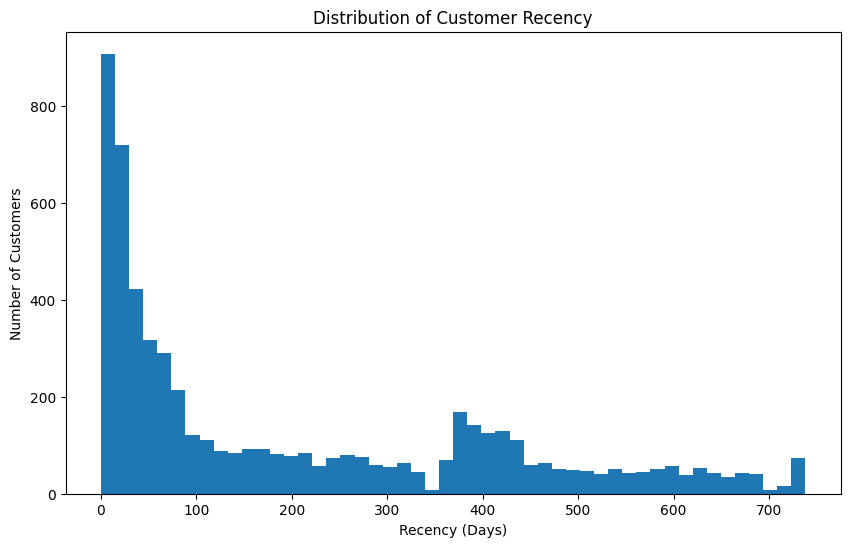

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(rfm["Recency"], bins=50)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

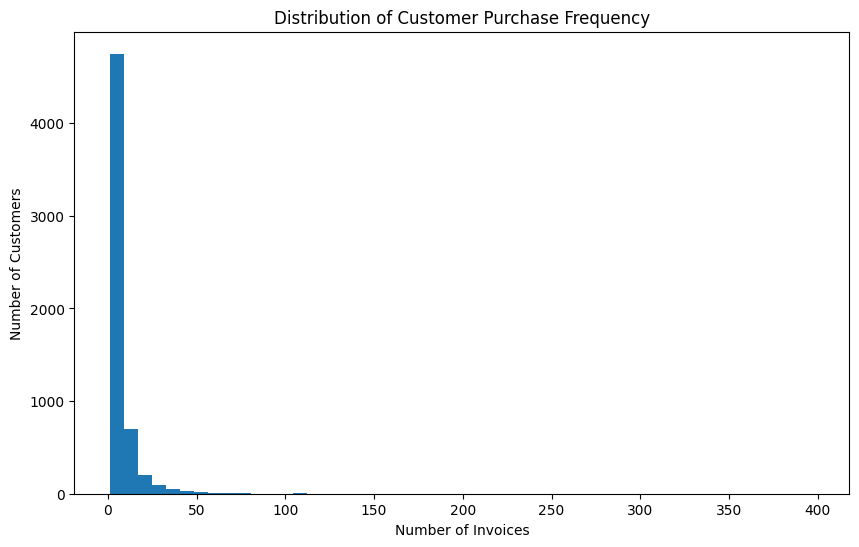

In [44]:
plt.figure(figsize=(10, 6))

plt.hist(rfm["Frequency"], bins=50)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Invoices")
plt.ylabel("Number of Customers")

plt.show()

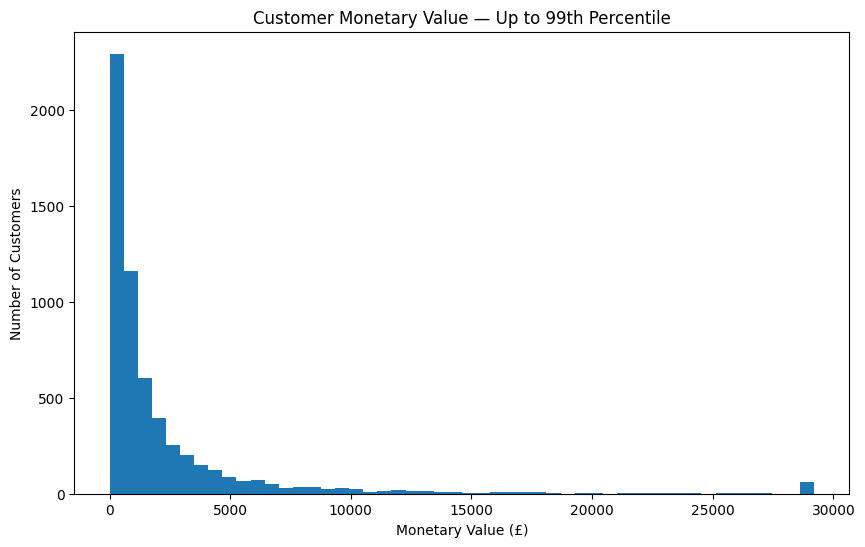

In [45]:
plt.figure(figsize=(10, 6))

plt.hist(
    rfm["Monetary"].clip(
        upper=rfm["Monetary"].quantile(0.99)
    ),
    bins=50
)

plt.title("Customer Monetary Value — Up to 99th Percentile")
plt.xlabel("Monetary Value (£)")
plt.ylabel("Number of Customers")

plt.show()

In [46]:
rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]].corr()

,Recency,Frequency,Monetary
Recency,1.00,-0.26,-0.13
Frequency,-0.26,1.00,0.63
Monetary,-0.13,0.63,1.00


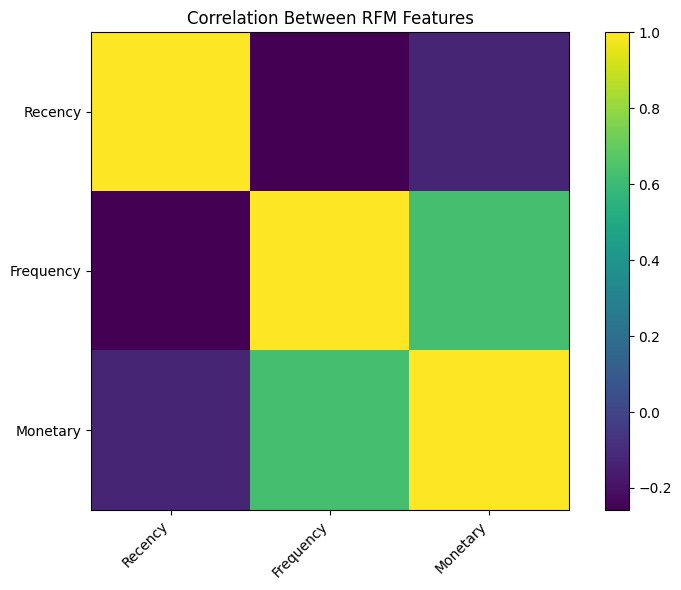

In [47]:
plt.figure(figsize=(8, 6))

corr = rfm[
    ["Recency", "Frequency", "Monetary"]
].corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Between RFM Features")

plt.tight_layout()

plt.show()

In [48]:
rfm.to_csv(
    "../data/processed/rfm_customer_features.csv",
    index=False
)

In [49]:
print(
    "Saved:",
    "../data/processed/rfm_customer_features.csv"
)

Saved: ../data/processed/rfm_customer_features.csv


In [50]:
feature_summary = pd.DataFrame({
    "Feature": [
        "Recency",
        "Frequency",
        "Monetary",
        "RFM Score",
        "RFM Segment",
        "AtRisk60"
    ],
    "Definition": [
        "Days since customer's last purchase",
        "Number of unique invoices/purchasing occasions",
        "Total customer revenue",
        "Sum of R, F and M scores",
        "Customer classification based on RFM score",
        "Customer inactive for at least 60 days"
    ]
})

feature_summary

,Feature,Definition
0,Recency,Days since customer's last purchase
1,Frequency,Number of unique invoices/purchasing occasions
2,Monetary,Total customer revenue
3,RFM Score,"Sum of R, F and M scores"
4,RFM Segment,Customer classification based on RFM score
5,AtRisk60,Customer inactive for at least 60 days
